# Prac 08.1

In this homework you are going to build your first classifier for the CIFAR-10 dataset. This dataset contains 10 different classes and you can learn more about it [here](https://www.cs.toronto.edu/~kriz/cifar.html). This homework consists of the following tasks:
* Dataset inspection
* Building the network
* Training
* Evaluation

At the end, as usual, there will be a couple of questions for you to answer :-)

In [25]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import tensorflow as tf
from collections import Counter
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, Input, MaxPooling2D
from tensorflow.keras import Model

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

### Step 0: Dataset Inspection

Load the dataset and make a quick inspection.

In [26]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

classes = {0:'plane', 1:'car', 2:'bird', 3:'cat', 4:'deer',
           5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}

num_classes = len(classes)
size = x_train.shape[1]

print(f'Train set: {x_train.shape}  labels: {y_train.shape}')
print(f'Test  set: {x_test.shape}   labels: {y_test.shape}')
print(f'Image size: {size}x{size}x{x_train.shape[3]},  classes: {num_classes}')

Train set: (50000, 32, 32, 3)  labels: (50000, 1)
Test  set: (10000, 32, 32, 3)   labels: (10000, 1)
Image size: 32x32x3,  classes: 10


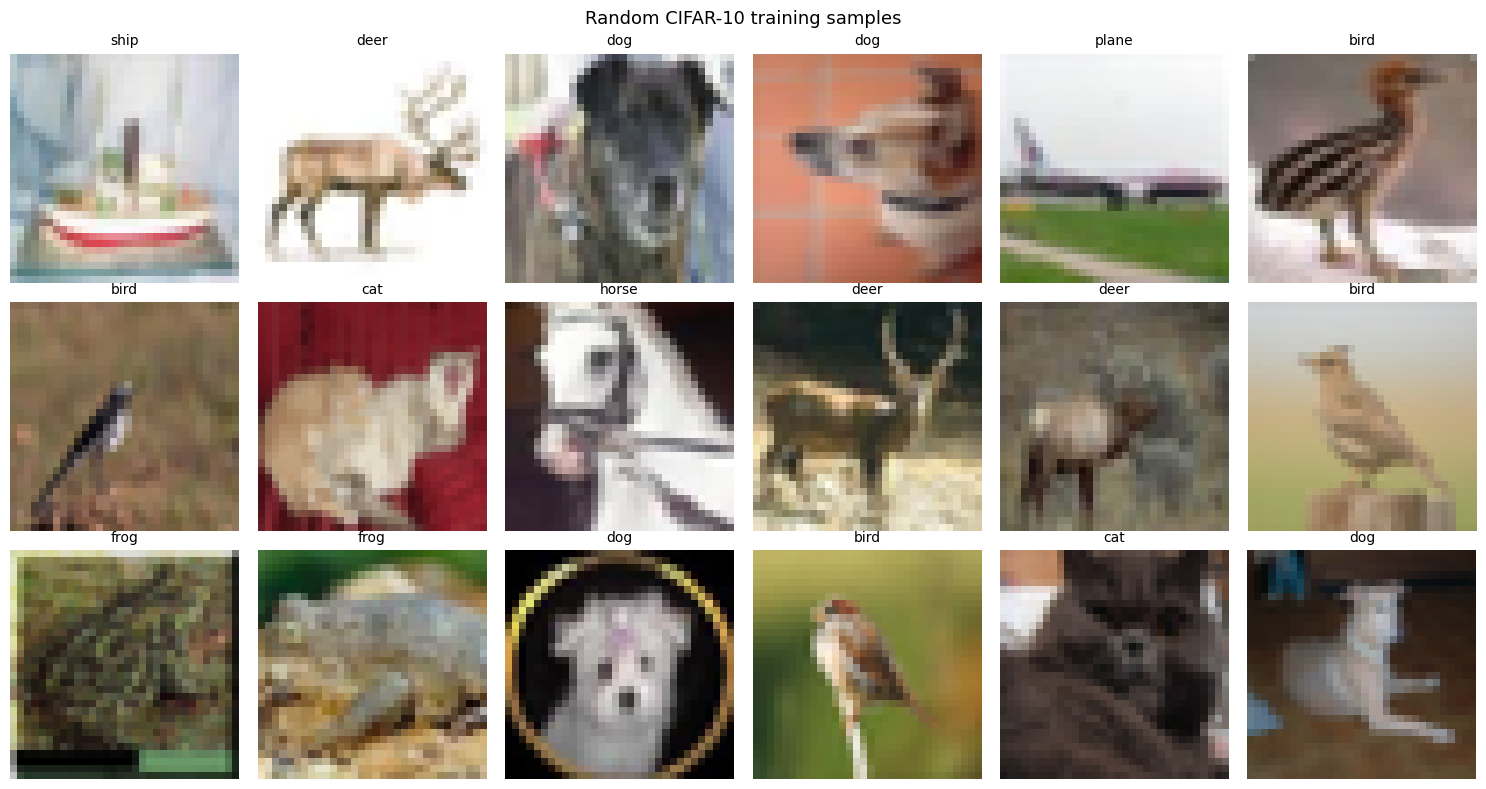

In [27]:
# Visualise random samples (3x6 grid)
np.random.seed(0)
plt.figure(figsize=(15, 8))
for ii in range(18):
    plt.subplot(3, 6, ii+1)
    idx = np.random.randint(len(x_train))
    plt.imshow(x_train[idx, ...])
    plt.title(classes[int(y_train[idx][0])], fontsize=10)
    plt.axis('off')
plt.suptitle('Random CIFAR-10 training samples', fontsize=13)
plt.tight_layout()

Counts per class: [5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000]
Dataset is perfectly balanced: each class has exactly 5000 training samples.


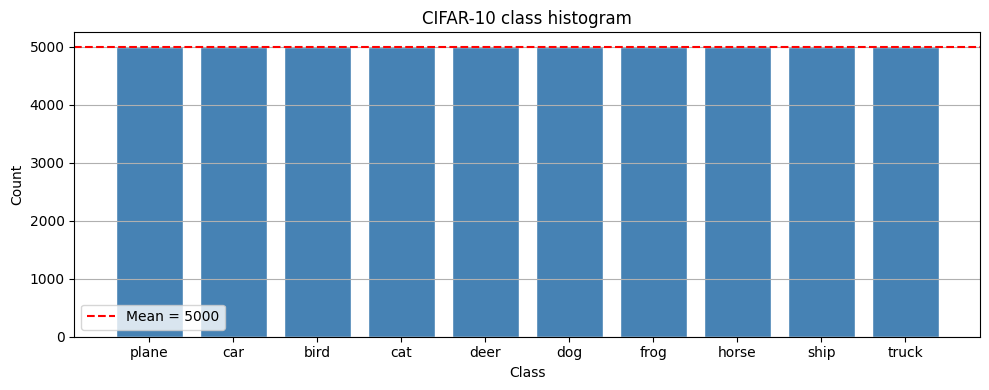

In [28]:
hist = Counter(y_train.flatten().tolist())
keys = sorted(hist.keys())
vals = [hist[k] for k in keys]

plt.figure(figsize=(10, 4))
plt.bar([classes[k] for k in keys], vals, color='steelblue', edgecolor='white')
plt.axhline(np.mean(vals), color='red', linestyle='--', label=f'Mean = {np.mean(vals):.0f}')
plt.xlabel('Class'), plt.ylabel('Count'), plt.title('CIFAR-10 class histogram')
plt.legend(), plt.grid(axis='y')
plt.tight_layout()

print(f'Counts per class: {vals}')
print('Dataset is perfectly balanced: each class has exactly 5000 training samples.')

### Step 1: Data Preparation

Normalize pixel values to [0, 1] and one-hot encode the labels.

In [29]:
# Normalisation
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# One-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test  = tf.keras.utils.to_categorical(y_test,  num_classes)

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test),  'samples')
print('Sample dims: ', x_train.shape)
print('Label shape: ', y_train.shape)

Train set:    50000 samples
Test set:     10000 samples
Sample dims:  (50000, 32, 32, 3)
Label shape:  (50000, 10)


### Step 2: Building the Classifier

We use the same CNN structure as the MNIST lesson, adapted for 32x32 RGB input and 10 output classes.

In [30]:
# Build the classifier
inputs = Input(shape=(size, size, 3))
net = Conv2D(32, (3, 3), activation='relu')(inputs)
net = MaxPooling2D((2, 2))(net)
net = Conv2D(64, (3, 3), activation='relu')(net)
net = MaxPooling2D((2, 2))(net)
net = Flatten()(net)
outputs = Dense(num_classes, activation='softmax')(net)

model = Model(inputs, outputs)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        23,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,442 (165.79 KB)

 Trainable params: 42,442 (165.79 KB)

 Non-trainable params: 0 (0.00 B)

### Step 3: Training

In [31]:
epochs = 25
batch_size = 128

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_split=0.1)

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4067 - loss: 1.6663 - val_accuracy: 0.4630 - val_loss: 1.5502
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5277 - loss: 1.3462 - val_accuracy: 0.5352 - val_loss: 1.3296
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5782 - loss: 1.2097 - val_accuracy: 0.5966 - val_loss: 1.1695
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6092 - loss: 1.1232 - val_accuracy: 0.6256 - val_loss: 1.0976
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6332 - loss: 1.0615 - val_accuracy: 0.6386 - val_loss: 1.0609
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6491 - loss: 1.0140 - val_accuracy: 0.6472 - val_loss: 1.0370
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6620 - loss: 0.9764 - val_accuracy: 0.6538 - val_loss: 1.0123
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6735 - loss: 0.9439 - val_accuracy: 0.

Train Acc      0.7703111171722412
Validation Acc 0.6977999806404114


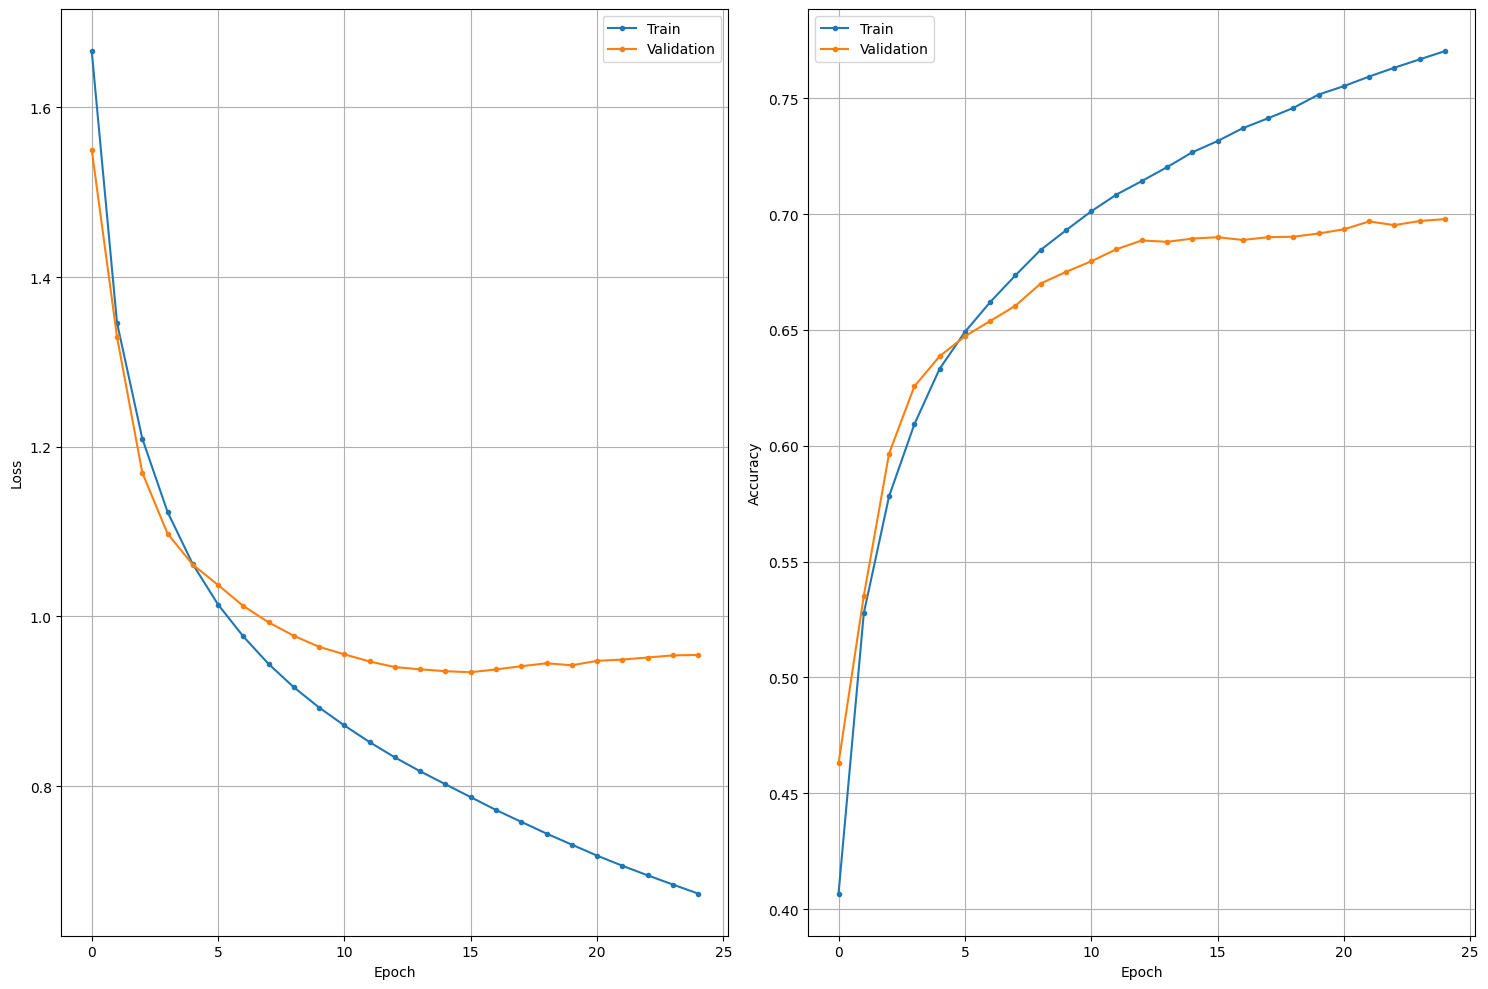

In [32]:
h = history.history
ep = range(len(h['loss']))

plt.subplot(121)
plt.plot(ep, h['loss'], '.-', ep, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('Epoch'), plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.subplot(122)
plt.plot(ep, h['accuracy'], '.-', ep, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('Epoch'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.tight_layout()

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])

### Step 4: Evaluation

In [33]:
# Sparse (integer) labels for per-class evaluation
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(x_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [38]:
# Per-class accuracy sorted descending
results = []
for class_id, class_name in classes.items():
    mask = (y_true == class_id)
    acc  = np.mean(y_pred[mask] == y_true[mask])
    results.append((acc, class_name))

for acc, class_name in sorted(results, reverse=True):
    print(f'{class_name:8s}  {acc:.4f}')

frog      0.8430
truck     0.8250
car       0.8190
horse     0.7790
plane     0.7140
deer      0.6980
ship      0.6740
dog       0.5310
bird      0.5030
cat       0.3940


In [35]:
ev = model.evaluate(x_test, y_test, verbose=0)
print('Test loss  ', ev[0])
print('Test metric', ev[1])

Test loss   0.9882736206054688
Test metric 0.6779999732971191


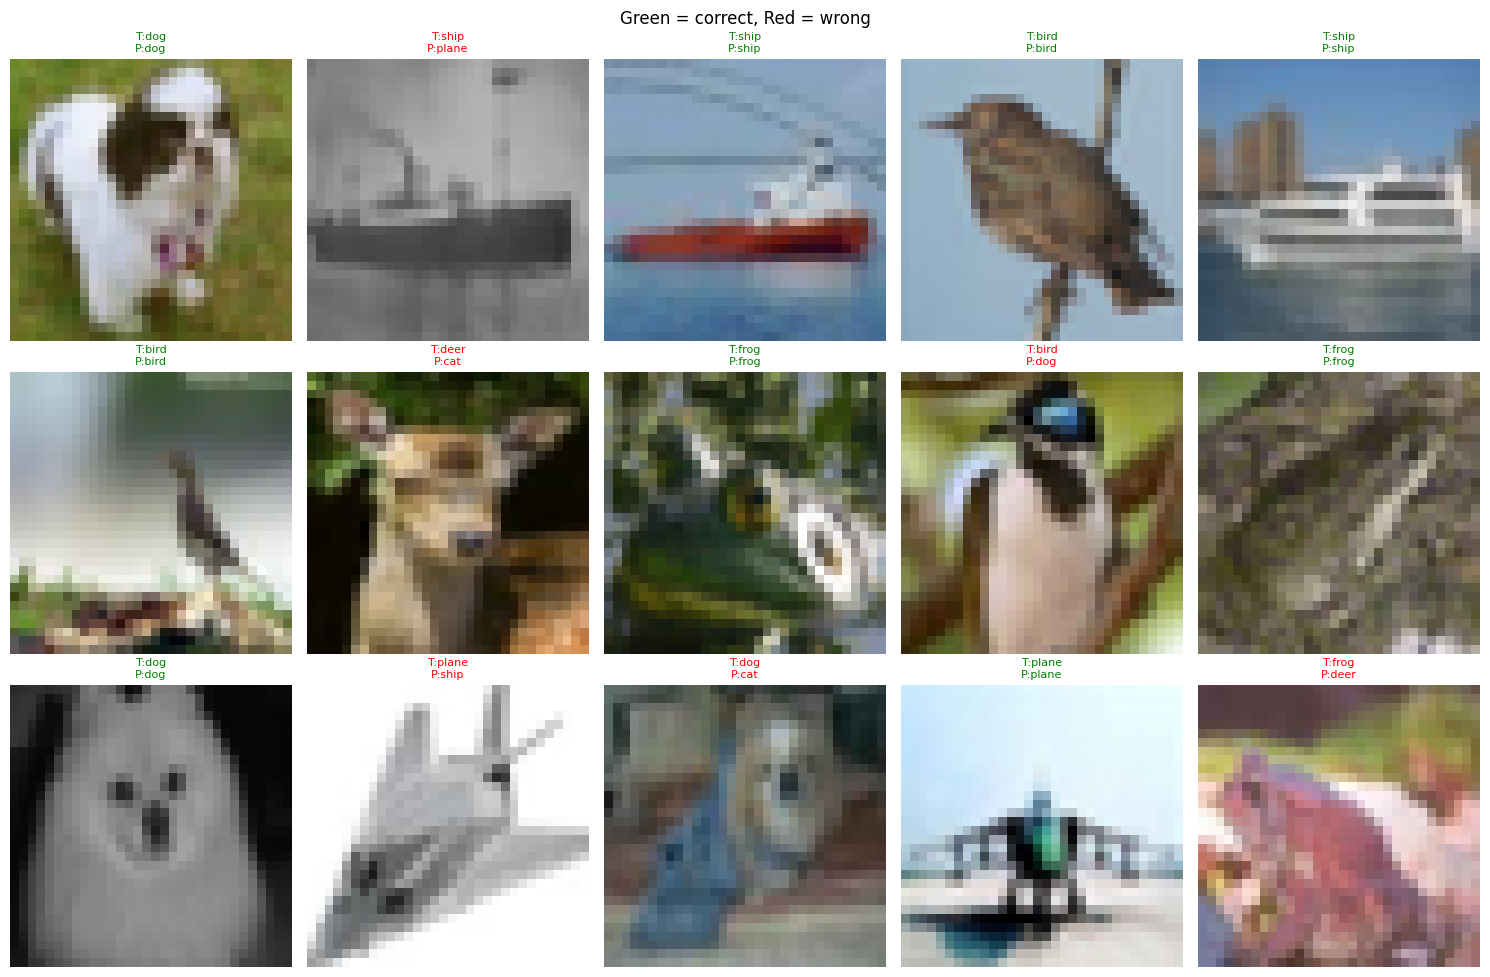

In [36]:
# Show 15 random test samples with predictions
np.random.seed(5)
for ii in range(15):
    idx = np.random.randint(len(x_test))
    plt.subplot(3, 5, ii+1)
    plt.imshow(x_test[idx, ...])
    color = 'green' if y_pred[idx] == y_true[idx] else 'red'
    plt.title(f'T:{classes[y_true[idx]]}\nP:{classes[y_pred[idx]]}', color=color, fontsize=8)
    plt.axis('off')
plt.suptitle('Green = correct, Red = wrong')
plt.tight_layout()

### Step 3b — Improved model

Adding **Dropout(0.4)** after the Flatten layer reduces overfitting and improves generalisation.

In [37]:
inputs2 = Input(shape=(size, size, 3))
net2 = Conv2D(32, (3, 3), activation='relu')(inputs2)
net2 = MaxPooling2D((2, 2))(net2)
net2 = Conv2D(64, (3, 3), activation='relu')(net2)
net2 = MaxPooling2D((2, 2))(net2)
net2 = Flatten()(net2)
net2 = Dropout(0.4)(net2)
outputs2 = Dense(num_classes, activation='softmax')(net2)

model2 = Model(inputs2, outputs2)
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history2 = model2.fit(x_train, y_train,
                      epochs=epochs, batch_size=batch_size, validation_split=0.1)

ev2 = model2.evaluate(x_test, y_test, verbose=0)
print(f'Original model test accuracy: {ev[1]:.4f}')
print(f'Improved model test accuracy: {ev2[1]:.4f}')

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3840 - loss: 1.7131 - val_accuracy: 0.4826 - val_loss: 1.4969
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5142 - loss: 1.3791 - val_accuracy: 0.5366 - val_loss: 1.3419
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5557 - loss: 1.2663 - val_accuracy: 0.5842 - val_loss: 1.2044
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5894 - loss: 1.1804 - val_accuracy: 0.6232 - val_loss: 1.1084
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6087 - loss: 1.1266 - val_accuracy: 0.6358 - val_loss: 1.0654
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6240 - loss: 1.0862 - val_accuracy: 0.6508 - val_loss: 1.0415
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6340 - loss: 1.0541 - val_accuracy: 0.6672 - val_loss: 0.9921
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6473 - loss: 1.0229 - val_accuracy: 0.

### Questions

**Q1: What is the overall accuracy of the classifier?**

The baseline 2-layer CNN achieved **67.80%** test accuracy after 25 epochs (train: 77.03%, val: 69.78%). The training–validation gap (~7 pp) indicates mild overfitting. Per-class results vary widely:

| Rank | Class | Accuracy |
|------|-------|----------|
| 1 | frog  | 84.30% |
| 2 | truck | 82.50% |
| 3 | car   | 81.90% |
| 4 | horse | 77.90% |
| 5 | plane | 71.40% |
| 6 | deer  | 69.80% |
| 7 | ship  | 67.40% |
| 8 | dog   | 53.10% |
| 9 | bird  | 50.30% |
| 10 | cat  | 39.40% |

Man-made objects with distinctive shapes (truck, car, frog) are easiest; visually similar animals (cat, dog, bird) are hardest — cat reaches only 39.4% because it is frequently confused with dog.

**Q2: What modifications would improve classification accuracy?**

- Add **Dropout** after the flatten or dense layers to reduce overfitting
- Add more convolutional layers or increase filter counts
- Use **Batch Normalization** to stabilise training
- Apply **data augmentation** (random flips, crops, colour jitter)
- Use a **deeper architecture** (e.g. VGG-like blocks)
- Train longer with a **learning rate schedule**

**Q3: One modification — Dropout(0.4) after Flatten**

Adding `Dropout(0.4)` after the Flatten layer raised test accuracy from **67.80% → 71.91%** (+4.1 pp). The training–validation gap nearly disappeared (train: 71.92%, val: 72.64%), confirming the model no longer overfits — validation accuracy actually exceeded training accuracy, which is the hallmark of effective regularisation.